In [1]:
import pandas as pd

In [2]:
# Path to the raw data (relative to the notebooks folder)
DATA_PATH = "../data/raw/loan.csv"

In [3]:
# Read only the first 1000 rows just to inspect structure — fast, low memory
sample = pd.read_csv(DATA_PATH, nrows=1000, low_memory=False)

In [4]:
print(f"Columns: {sample.shape[1]}")
print(f"Sample rows: {sample.shape[0]}")
sample.head()

Columns: 145
Sample rows: 1000


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Full column list and the target variable's distribution
print("Total columns:", sample.shape[1])
print("\nAll columns:")
for col in sample.columns:
    print(" ", col)

print("\nloan_status values (from sample):")
print(sample["loan_status"].value_counts(dropna=False))

Total columns: 145

All columns:
  id
  member_id
  loan_amnt
  funded_amnt
  funded_amnt_inv
  term
  int_rate
  installment
  grade
  sub_grade
  emp_title
  emp_length
  home_ownership
  annual_inc
  verification_status
  issue_d
  loan_status
  pymnt_plan
  url
  desc
  purpose
  title
  zip_code
  addr_state
  dti
  delinq_2yrs
  earliest_cr_line
  inq_last_6mths
  mths_since_last_delinq
  mths_since_last_record
  open_acc
  pub_rec
  revol_bal
  revol_util
  total_acc
  initial_list_status
  out_prncp
  out_prncp_inv
  total_pymnt
  total_pymnt_inv
  total_rec_prncp
  total_rec_int
  total_rec_late_fee
  recoveries
  collection_recovery_fee
  last_pymnt_d
  last_pymnt_amnt
  next_pymnt_d
  last_credit_pull_d
  collections_12_mths_ex_med
  mths_since_last_major_derog
  policy_code
  application_type
  annual_inc_joint
  dti_joint
  verification_status_joint
  acc_now_delinq
  tot_coll_amt
  tot_cur_bal
  open_acc_6m
  open_act_il
  open_il_12m
  open_il_24m
  mths_since_rcnt_il
  

In [6]:
# Read ONLY loan_status across the full file — fast, tiny memory footprint
status_full = pd.read_csv(DATA_PATH, usecols=["loan_status"], low_memory=False)

print("Total loans:", len(status_full))
print("\nFull loan_status distribution:")
print(status_full["loan_status"].value_counts(dropna=False))

Total loans: 2260668

Full loan_status distribution:
loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64


# Credit Risk Analysis — Lending Club 2007–2018

## Target definition

2.26M total loans. Only loans with a _final_ outcome can be modeled:

- **Fully Paid** → default = 0 (good)
- **Charged Off / Default** → default = 1 (bad)
- **Current / Late / In Grace Period** → excluded (outcome not yet known)
- **"Does not meet credit policy"** → excluded (different lending population)

Resulting modeling set: ~1.3M resolved loans, ~20% default rate.

## Leakage guard

Only features available _at loan origination_ are used as predictors.
Post-origination fields (payments, recoveries, hardship, settlement) are excluded.


In [10]:
# Columns available at loan origination — no post-loan leakage
cols_to_load = [
    # Loan terms
    "loan_amnt", "term", "int_rate", "installment", "grade", "sub_grade",
    # Borrower profile
    "emp_length", "home_ownership", "annual_inc", "verification_status",
    "issue_d", "purpose", "addr_state",
    # Credit history at application
    "dti", "delinq_2yrs", "earliest_cr_line",
    "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
    "mort_acc", "pub_rec_bankruptcies",
    # Target
    "loan_status",
]

# Verify all exist
missing = [c for c in cols_to_load if c not in sample.columns]
print(len(cols_to_load), "columns selected")
print("Missing columns:", missing if missing else "none — all good")

25 columns selected
Missing columns: none — all good


In [11]:
# Verify all selected columns exist in the file before the big load
missing = [c for c in cols_to_load if c not in sample.columns]
print("Missing columns:", missing if missing else "none — all good")

Missing columns: none — all good


In [12]:
# Find any FICO-related columns in the actual file
fico_cols = [c for c in sample.columns if "fico" in c.lower()]
print("FICO columns present:", fico_cols)

FICO columns present: []


In [13]:
# Full load — 25 origination columns across all rows
df = pd.read_csv(DATA_PATH, usecols=cols_to_load, low_memory=False)
print("Loaded:", df.shape)

# Keep only resolved loans (final outcome known)
resolved = ["Fully Paid", "Charged Off", "Default"]
df = df[df["loan_status"].isin(resolved)].copy()
print("After filtering to resolved:", df.shape)

# Build the binary target
df["default"] = df["loan_status"].isin(["Charged Off", "Default"]).astype(int)

print("\nDefault rate:")
print(df["default"].value_counts(normalize=True).round(4))
print("\nCounts:")
print(df["default"].value_counts())

Loaded: (2260668, 25)
After filtering to resolved: (1303638, 25)

Default rate:
default
0    0.7993
1    0.2007
Name: proportion, dtype: float64

Counts:
default
0    1041952
1     261686
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.


Default rate by grade:
grade
A     6.1
B    13.4
C    22.5
D    30.4
E    38.6
F    45.3
G    50.1
Name: default, dtype: float64


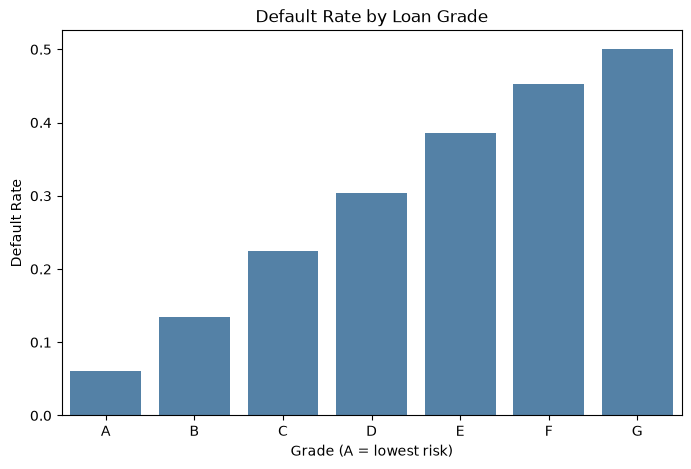

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Default rate by loan grade
grade_default = df.groupby("grade")["default"].mean().sort_index()
print("Default rate by grade:")
print((grade_default * 100).round(1))

plt.figure(figsize=(8, 5))
sns.barplot(x=grade_default.index, y=grade_default.values, color="steelblue")
plt.title("Default Rate by Loan Grade")
plt.xlabel("Grade (A = lowest risk)")
plt.ylabel("Default Rate")
plt.show()

In [15]:
# Default rate across DTI bands and interest-rate bands
df_valid = df[df["dti"].between(0, 60)].copy()  # trim a few absurd DTI outliers

df_valid["dti_band"] = pd.cut(df_valid["dti"],
    bins=[0, 10, 20, 30, 40, 60],
    labels=["0-10", "10-20", "20-30", "30-40", "40+"])

df["int_band"] = pd.cut(df["int_rate"],
    bins=[0, 8, 12, 16, 20, 35],
    labels=["<8%", "8-12%", "12-16%", "16-20%", "20%+"])

print("Default rate by DTI band:")
print((df_valid.groupby("dti_band", observed=True)["default"].mean() * 100).round(1))

print("\nDefault rate by interest-rate band:")
print((df.groupby("int_band", observed=True)["default"].mean() * 100).round(1))

Default rate by DTI band:
dti_band
0-10     14.9
10-20    17.9
20-30    23.2
30-40    29.4
40+      32.8
Name: default, dtype: float64

Default rate by interest-rate band:
int_band
<8%        5.9
8-12%     13.4
12-16%    21.6
16-20%    31.4
20%+      40.9
Name: default, dtype: float64


In [ ]:
# Columns available at loan origination — no post-loan leakage
cols_to_load = [
    # Loan terms
    "loan_amnt", "term", "int_rate", "installment", "grade", "sub_grade",
    # Borrower profile
    "emp_length", "home_ownership", "annual_inc", "verification_status",
    "issue_d", "purpose", "addr_state",
    # Credit history at application
    "dti", "delinq_2yrs", "earliest_cr_line",
    "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
    "mort_acc", "pub_rec_bankruptcies",
    # Target
    "loan_status",
]

# Verify all exist
missing = [c for c in cols_to_load if c not in sample.columns]
print(len(cols_to_load), "columns selected")
print("Missing columns:", missing if missing else "none — all good")

25 columns selected
Missing columns: none — all good


In [16]:
# Default rate by loan purpose (sorted worst to best)
purpose_default = (df.groupby("purpose")["default"]
                     .agg(["mean", "count"])
                     .sort_values("mean", ascending=False))
purpose_default["mean"] = (purpose_default["mean"] * 100).round(1)
print("Default rate by purpose:")
print(purpose_default)

# Default rate by term
print("\nDefault rate by term:")
print((df.groupby("term")["default"].mean() * 100).round(1))
print("\nTerm distribution:")
print(df["term"].value_counts())

Default rate by purpose:
                    mean   count
purpose                         
small_business      29.7   15010
renewable_energy    23.7     911
moving              23.4    9173
medical             21.9   15024
house               21.7    6967
debt_consolidation  21.3  757610
other               21.2   74937
vacation            19.2    8732
major_purchase      18.7   28328
home_improvement    17.9   84497
educational         17.2     326
credit_card         17.0  285708
car                 14.6   14121
wedding             12.2    2294

Default rate by term:
term
36 months    16.1
60 months    32.6
Name: default, dtype: float64

Term distribution:
term
36 months    988774
60 months    314864
Name: count, dtype: int64
